In [14]:
import json
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import class_weight
import seaborn as s

In [15]:
X_train = pd.read_csv("train.csv")
X_val = pd.read_csv("val.csv")
X_test = pd.read_csv("test.csv")

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (4924, 12)
Validation shape: (1055, 12)
Test shape: (1056, 12)


In [16]:
y_train = np.load("y_train.npy")
y_val = np.load("y_val.npy")
y_test = np.load("y_test.npy")

print(f"Train shape: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print(f"Label shape: {y_train.shape}, {y_val.shape}, {y_test.shape}")

Train shape: (4924, 12), Validation: (1055, 12), Test: (1056, 12)
Label shape: (4924, 7), (1055, 7), (1056, 7)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Determine input and output dimensions
input_dim = X_train.shape[1]    # 11 features
output_dim = y_train.shape[1]   # number of classes (7)

# ============================
# BUILD MODEL
# ============================
model = Sequential()
model.add(Dense(96, activation='relu', input_shape=(input_dim,)))
model.add(Dense(96, activation='relu'))
model.add(Dense(output_dim, activation='softmax'))


# === Compile ===
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('model_1.h5', monitor='val_accuracy', save_best_only=True)

model.summary()


c:\Users\aaaxx\miniconda3\envs\AttendanceSystem33\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 96)             │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │           679 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,239 (43.90 KB)

 Trainable params: 11,239 (43.90 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=100,
                    batch_size=32,
                    callbacks=[early_stop, checkpoint])


Epoch 1/100
142/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3520 - loss: 1.6992

154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3581 - loss: 1.6835 - val_accuracy: 0.5024 - val_loss: 1.2635
Epoch 2/100
149/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5416 - loss: 1.1913

154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5417 - loss: 1.1897 - val_accuracy: 0.5573 - val_loss: 1.1168
Epoch 3/100
121/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5754 - loss: 1.0480

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5759 - loss: 1.0462 - val_accuracy: 0.5592 - val_loss: 1.0301
Epoch 4/100
134/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6084 - loss: 0.9726

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6084 - loss: 0.9719 - val_accuracy: 0.5810 - val_loss: 0.9894
Epoch 5/100
150/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6295 - loss: 0.9137

...

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8661 - loss: 0.3469 - val_accuracy: 0.7697 - val_loss: 0.6427
Epoch 63/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8680 - loss: 0.3511 - val_accuracy: 0.7611 - val_loss: 0.6346
Epoch 64/100
144/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8661 - loss: 0.3558

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8662 - loss: 0.3555 - val_accuracy: 0.7706 - val_loss: 0.6237
Epoch 65/100
124/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8625 - loss: 0.3426

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8632 - loss: 0.3433 - val_accuracy: 0.7773 - val_loss: 0.6462
Epoch 66/100
141/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8633 - loss: 0.3387

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8637 - loss: 0.3389 - val_accuracy: 0.7801 - val_loss: 0.6337
Epoch 67/100
135/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8821 - loss: 0.3122

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8809 - loss: 0.3150 - val_accuracy: 0.7829 - val_loss: 0.6389
Epoch 68/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8811 - loss: 0.3200 - val_accuracy: 0.7725 - val_loss: 0.6485
Epoch 69/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8849 - loss: 0.3187 - val_accuracy: 0.7735 - val_loss: 0.6329


In [19]:
# === Save training history ===
with open("training_history_model1.json", "w") as f:
    json.dump(history.history, f)


In [ ]:
# === Evaluate ===
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)



33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7618 - loss: 0.6732 
Test Accuracy: 0.7642
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       149
           1       0.85      0.90      0.87       162
           2       0.58      0.59      0.58       150
           3       0.46      0.33      0.39       150
           4       0.62      0.55      0.59       150
           5       0.75      0.98      0.85       145
           6       1.00      1.00      1.00       150

    accuracy                           0.76      1056
   macro avg       0.75      0.76      0.75      1056
weighted avg       0.75      0.76      0.75      1056

[[149   0   0   0   0   0   0]
 [  0 145  15   1   1   0   0]
 [  2  14  88  31  13   2   0]
 [  2  10  39  50  35  14   0]
 [  0   1  10  24  83  32   0]
 [  0   0   0   2   1 142   0]
 [  0   0   0   0   0   0 150]]


In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

# === Classification Report as DataFrame ===
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Remove 'accuracy', 'macro avg', and 'weighted avg' rows (optional)
metrics_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# === Visualize as Heatmap ===
plt.figure(figsize=(8, 5))
sns.heatmap(metrics_df.iloc[:, :3], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Classification Report (Precision, Recall, F1-score)")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Pred {i}" for i in range(y_train.shape[1])],
            yticklabels=[f"True {i}" for i in range(y_train.shape[1])])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


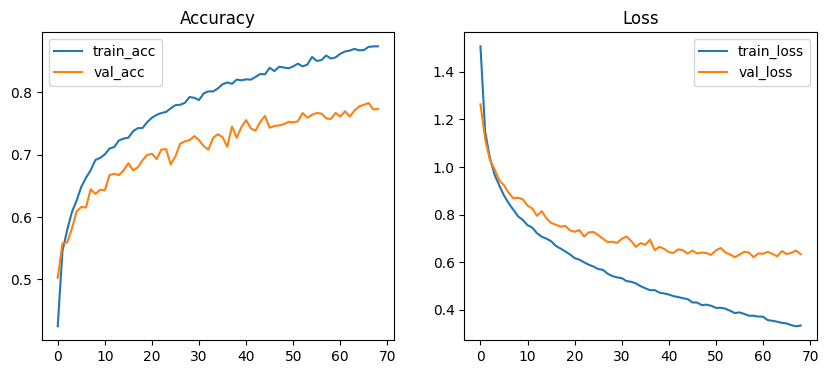

In [21]:
# === Plot training ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.savefig("model1_training_curves.png")
plt.show()

In [22]:
# === Model Architecture ===
model2 = Sequential()
model2.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(BatchNormalization())
model2.add(Dropout(0.3))
model2.add(Dense(96, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.3))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(y_train.shape[1], activation='softmax'))


c:\Users\aaaxx\miniconda3\envs\AttendanceSystem33\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:

# === Compile ===
model2.compile(optimizer=RMSprop(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [24]:
# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
checkpoint = ModelCheckpoint('model_2.h5', monitor='val_accuracy', save_best_only=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

In [25]:
# === Train ===
history = model2.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=120,
                    batch_size=32,
                    callbacks=[early_stop, checkpoint, lr_schedule])


Epoch 1/120
137/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3082 - loss: 1.8078

154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3168 - loss: 1.7804 - val_accuracy: 0.5100 - val_loss: 1.3983 - learning_rate: 0.0010
Epoch 2/120
128/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4752 - loss: 1.3020

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4778 - loss: 1.2962 - val_accuracy: 0.5336 - val_loss: 1.1199 - learning_rate: 0.0010
Epoch 3/120
152/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5283 - loss: 1.1734

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5283 - loss: 1.1733 - val_accuracy: 0.5962 - val_loss: 0.9991 - learning_rate: 0.0010
Epoch 4/120
151/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5218 - loss: 1.1432

154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5221 - loss: 1.1427 - val_accuracy: 0.6123 - val_loss: 0.9502 - learning_rate: 0.0010
Epoch 5/120
134/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5653 - loss: 1.0861

...

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7357 - loss: 0.6580 - val_accuracy: 0.7460 - val_loss: 0.6281 - learning_rate: 5.0000e-04
Epoch 67/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7315 - loss: 0.6631 - val_accuracy: 0.7384 - val_loss: 0.6196 - learning_rate: 5.0000e-04
Epoch 68/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7343 - loss: 0.6600 - val_accuracy: 0.7365 - val_loss: 0.6225 - learning_rate: 5.0000e-04
Epoch 69/120
129/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7461 - loss: 0.6217

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7448 - loss: 0.6250 - val_accuracy: 0.7479 - val_loss: 0.6279 - learning_rate: 5.0000e-04
Epoch 70/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7429 - loss: 0.6262 - val_accuracy: 0.7431 - val_loss: 0.6229 - learning_rate: 5.0000e-04
Epoch 71/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7268 - loss: 0.6565 - val_accuracy: 0.7384 - val_loss: 0.6319 - learning_rate: 5.0000e-04
Epoch 72/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7393 - loss: 0.6558 - val_accuracy: 0.7355 - val_loss: 0.6359 - learning_rate: 5.0000e-04
Epoch 73/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7328 - loss: 0.6452 - val_accuracy: 0.7450 - val_loss: 0.6238 - learning_rate: 2.5000e-04
Epoch 74/120
130/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.6650

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7324 - loss: 0.6598 - val_accuracy: 0.7498 - val_loss: 0.6199 - learning_rate: 2.5000e-04
Epoch 75/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7398 - loss: 0.6401 - val_accuracy: 0.7460 - val_loss: 0.6204 - learning_rate: 2.5000e-04
Epoch 76/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7490 - loss: 0.6184 - val_accuracy: 0.7403 - val_loss: 0.6178 - learning_rate: 2.5000e-04
Epoch 77/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7318 - loss: 0.6533 - val_accuracy: 0.7498 - val_loss: 0.6194 - learning_rate: 2.5000e-04
Epoch 78/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7446 - loss: 0.6326 - val_accuracy: 0.7412 - val_loss: 0.6151 - learning_rate: 2.5000e-04
Epoch 79/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7586 - loss: 0.6181 - val_accuracy: 0.7469 - val_loss: 0.6097 - learning_rate: 2.5000e-04
Epoch 80/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7407 - loss: 0.6168 - val_accuracy: 0.7526 - val_loss: 0.6192 - learning_rate: 1.2500e-04
Epoch 86/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7476 - loss: 0.6135 - val_accuracy: 0.7479 - val_loss: 0.6159 - learning_rate: 1.2500e-04
Epoch 87/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7573 - loss: 0.6032 - val_accuracy: 0.7431 - val_loss: 0.6204 - learning_rate: 1.2500e-04
Epoch 88/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7514 - loss: 0.6125 - val_accuracy: 0.7479 - val_loss: 0.6185 - learning_rate: 1.2500e-04
Epoch 89/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7457 - loss: 0.6149 - val_accuracy: 0.7479 - val_loss: 0.6169 - learning_rate: 1.2500e-04
Epoch 90/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7600 - loss: 0.6126 - val_accuracy: 0.7498 - val_loss: 0.6194 - learning_rate: 6.2500e-05
Epoch 91/120
151/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7528 - loss: 0.6133 - val_accuracy: 0.7545 - val_loss: 0.6148 - learning_rate: 6.2500e-05


In [26]:
# === Save training history ===
with open("training_history_model2.json", "w") as f:
    json.dump(history.history, f)


In [ ]:

# === Evaluate ===
test_loss, test_acc = model2.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = np.argmax(model2.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)



33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7546 - loss: 0.6382
Test Accuracy: 0.7538
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       149
           1       0.77      0.91      0.84       162
           2       0.63      0.57      0.60       150
           3       0.50      0.35      0.41       150
           4       0.59      0.49      0.53       150
           5       0.70      0.95      0.81       145
           6       0.99      1.00      0.99       150

    accuracy                           0.75      1056
   macro avg       0.74      0.75      0.74      1056
weighted avg       0.74      0.75      0.74      1056

[[149   0   0   0   0   0   0]
 [  0 148   9   1   0   4   0]
 [  1  23  86  28  11   1   0]
 [  1  16  33  52  33  14   1]
 [  0   4   8  24  73  40   1]
 [  0   0   0   0   7 138   0]
 [  0   0   0   0   0   0 150]]


In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

# === Classification Report as DataFrame ===
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Remove 'accuracy', 'macro avg', and 'weighted avg' rows (optional)
metrics_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# === Visualize as Heatmap ===
plt.figure(figsize=(8, 5))
sns.heatmap(metrics_df.iloc[:, :3], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Classification Report (Precision, Recall, F1-score)")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Pred {i}" for i in range(y_train.shape[1])],
            yticklabels=[f"True {i}" for i in range(y_train.shape[1])])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


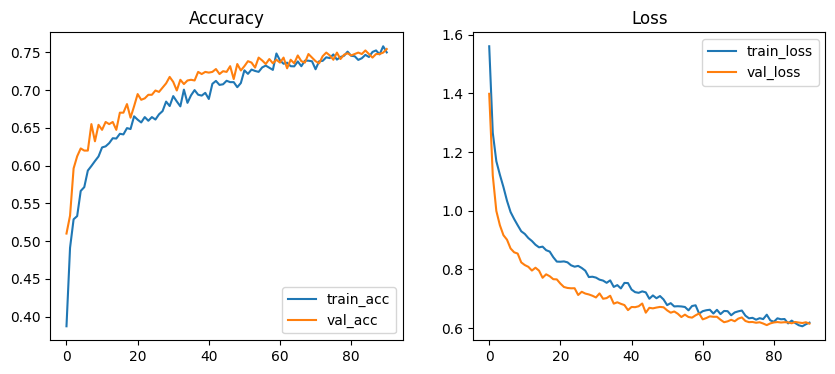

In [28]:

# === Plot training ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.savefig("model2_training_curves.png")
plt.show()


In [40]:
# === Model Architecture ===
model3 = Sequential()
model3.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.001)))
model3.add(Dropout(0.5))
model3.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model3.add(Dropout(0.2))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(y_train.shape[1], activation='softmax'))

c:\Users\aaaxx\miniconda3\envs\AttendanceSystem33\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
# === Compile ===
optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model3.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [42]:
# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint('model_3.h5', monitor='val_accuracy', save_best_only=True)


In [43]:
# === Train ===
history = model3.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=150,
                    batch_size=64,
                    callbacks=[early_stop, checkpoint])

Epoch 1/150


40/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1624 - loss: 2.0526   

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1930 - loss: 2.0143 - val_accuracy: 0.3630 - val_loss: 1.7318
Epoch 2/150
55/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3749 - loss: 1.7370

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3779 - loss: 1.7163 - val_accuracy: 0.4616 - val_loss: 1.4509
Epoch 3/150
55/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4336 - loss: 1.5086

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4346 - loss: 1.5013 - val_accuracy: 0.4626 - val_loss: 1.3595
Epoch 4/150
55/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4515 - loss: 1.4333

...

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6591 - loss: 0.8905 - val_accuracy: 0.6758 - val_loss: 0.8433
Epoch 110/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6583 - loss: 0.8919 - val_accuracy: 0.6635 - val_loss: 0.8521
Epoch 111/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6630 - loss: 0.8931 - val_accuracy: 0.6664 - val_loss: 0.8342
Epoch 112/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6651 - loss: 0.9171 - val_accuracy: 0.6645 - val_loss: 0.8472
Epoch 113/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6651 - loss: 0.8932 - val_accuracy: 0.6664 - val_loss: 0.8382
Epoch 114/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6654 - loss: 0.8771 - val_accuracy: 0.6626 - val_loss: 0.8480
Epoch 115/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6689 - loss: 0.8813 - val_accuracy: 0.6588 - val_loss: 0.8445
Epoch 116/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6734 - loss: 0.8853 - val_accuracy: 0.6645 -

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6517 - loss: 0.9169 - val_accuracy: 0.6787 - val_loss: 0.8402
Epoch 121/150
75/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6535 - loss: 0.9112

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6537 - loss: 0.9110 - val_accuracy: 0.6806 - val_loss: 0.8484
Epoch 122/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6477 - loss: 0.9049 - val_accuracy: 0.6626 - val_loss: 0.8368
Epoch 123/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6591 - loss: 0.9005 - val_accuracy: 0.6730 - val_loss: 0.8397
Epoch 124/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6518 - loss: 0.9056 - val_accuracy: 0.6739 - val_loss: 0.8342
Epoch 125/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6471 - loss: 0.9008 - val_accuracy: 0.6787 - val_loss: 0.8405
Epoch 126/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6689 - loss: 0.8862 - val_accuracy: 0.6787 - val_loss: 0.8344
Epoch 127/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6715 - loss: 0.8769 - val_accuracy: 0.6777 - val_loss: 0.8399
Epoch 128/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6815 - loss: 0.8759 - val_accuracy: 0.6701 -

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6574 - loss: 0.9133 - val_accuracy: 0.6834 - val_loss: 0.8434
Epoch 130/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6672 - loss: 0.8932 - val_accuracy: 0.6768 - val_loss: 0.8374
Epoch 131/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6751 - loss: 0.8700 - val_accuracy: 0.6796 - val_loss: 0.8326
Epoch 132/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6793 - loss: 0.8736 - val_accuracy: 0.6673 - val_loss: 0.8310
Epoch 133/150
71/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6663 - loss: 0.8862

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6658 - loss: 0.8864 - val_accuracy: 0.6900 - val_loss: 0.8334


In [44]:
# === Save training history ===
with open("training_history_model3.json", "w") as f:
    json.dump(history.history, f)


In [ ]:
# === Evaluate ===
test_loss, test_acc = model3.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

In [ ]:
y_pred = np.argmax(model3.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)



In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

# === Classification Report as DataFrame ===
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Remove 'accuracy', 'macro avg', and 'weighted avg' rows (optional)
metrics_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# === Visualize as Heatmap ===
plt.figure(figsize=(8, 5))
sns.heatmap(metrics_df.iloc[:, :3], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Classification Report (Precision, Recall, F1-score)")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Pred {i}" for i in range(y_train.shape[1])],
            yticklabels=[f"True {i}" for i in range(y_train.shape[1])])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7483 - loss: 0.7250
Test Accuracy: 0.7500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       149
           1       0.77      0.91      0.84       162
           2       0.66      0.57      0.61       150
           3       0.45      0.31      0.37       150
           4       0.55      0.54      0.55       150
           5       0.72      0.92      0.81       145
           6       0.99      1.00      0.99       150

    accuracy                           0.75      1056
   macro avg       0.73      0.75      0.74      1056
weighted avg       0.73      0.75      0.74      1056

[[149   0   0   0   0   0   0]
 [  0 148  10   4   0   0   0]
 [  0  25  85  26  12   2   0]
 [  0  15  30  46  42  16   1]
 [  1   3   4  26  81  34   1]
 [  0   0   0   0  12 133   0]
 [  0   0   0   0   0   0 150]]


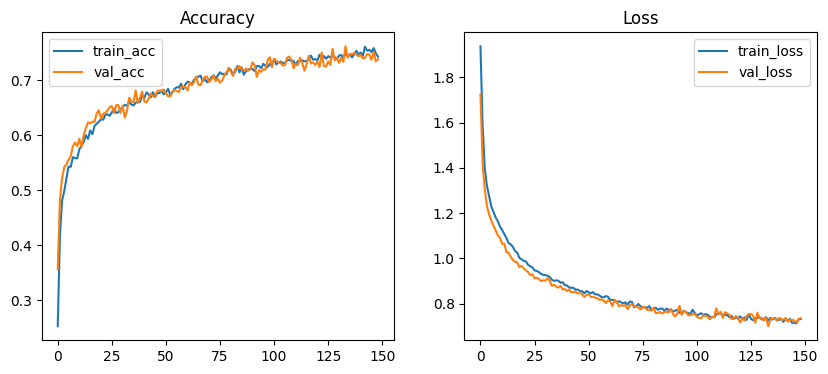

In [ ]:



# === Plot training ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.savefig("model3_training_curves.png")
plt.show()


In [45]:
# === Model Architecture (4 Hidden Layers, ReLU) ===
model4 = Sequential([
    Dense(96, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(96, activation='relu'),
    Dense(96, activation='relu'),
    Dense(96, activation='relu'),
    Dense(y_train.shape[1], activation='softmax')
])


c:\Users\aaaxx\miniconda3\envs\AttendanceSystem33\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
# === Compile Model ===
model4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [47]:
# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('wine_model_fc4_adam.h5', monitor='val_accuracy', save_best_only=True)


In [48]:
# === Train Model ===
history = model4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/100
35/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2742 - loss: 1.8448 

77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3322 - loss: 1.7055 - val_accuracy: 0.5043 - val_loss: 1.1796
Epoch 2/100
68/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5467 - loss: 1.1187

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5479 - loss: 1.1140 - val_accuracy: 0.5820 - val_loss: 1.0358
Epoch 3/100
74/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5894 - loss: 0.9889

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5903 - loss: 0.9874 - val_accuracy: 0.6104 - val_loss: 0.9418
Epoch 4/100
73/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6412 - loss: 0.8751

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6410 - loss: 0.8752 - val_accuracy: 0.6161 - val_loss: 0.8982
Epoch 5/100
59/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6734 - loss: 0.8302

...

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9049 - loss: 0.2513 - val_accuracy: 0.7972 - val_loss: 0.5852
Epoch 41/100
59/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9091 - loss: 0.2399

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9080 - loss: 0.2439 - val_accuracy: 0.7981 - val_loss: 0.6867
Epoch 42/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9092 - loss: 0.2468 - val_accuracy: 0.7858 - val_loss: 0.6162
Epoch 43/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9025 - loss: 0.2446 - val_accuracy: 0.7621 - val_loss: 0.7064
Epoch 44/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8974 - loss: 0.2733 - val_accuracy: 0.7810 - val_loss: 0.6593
Epoch 45/100
66/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9083 - loss: 0.2382

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9076 - loss: 0.2388 - val_accuracy: 0.8000 - val_loss: 0.5736
Epoch 46/100
33/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9246 - loss: 0.2091 

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9199 - loss: 0.2150 - val_accuracy: 0.8009 - val_loss: 0.6231
Epoch 47/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9199 - loss: 0.2182 - val_accuracy: 0.8009 - val_loss: 0.6056
Epoch 48/100
68/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9210 - loss: 0.2132

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9202 - loss: 0.2137 - val_accuracy: 0.8104 - val_loss: 0.6188
Epoch 49/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9235 - loss: 0.2089 - val_accuracy: 0.8009 - val_loss: 0.6788


In [49]:
# === Save training history ===
with open("training_history_wine_fc4_adam.json", "w") as f:
    json.dump(history.history, f)


In [50]:
# === Evaluate ===
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7618 - loss: 0.6732
Test Accuracy: 0.7642


In [54]:
# === Predictions and Metrics ===
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


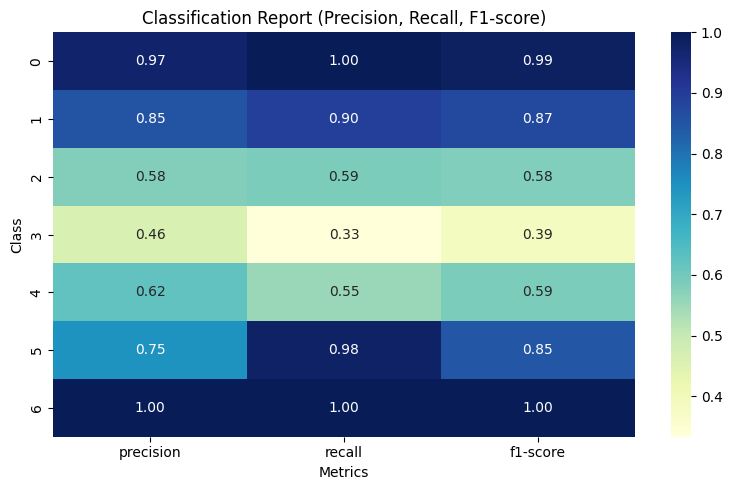

In [63]:
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

# === Classification Report as DataFrame ===
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Remove 'accuracy', 'macro avg', and 'weighted avg' rows (optional)
metrics_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# === Visualize as Heatmap ===
plt.figure(figsize=(8, 5))
sns.heatmap(metrics_df.iloc[:, :3], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Classification Report (Precision, Recall, F1-score)")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()


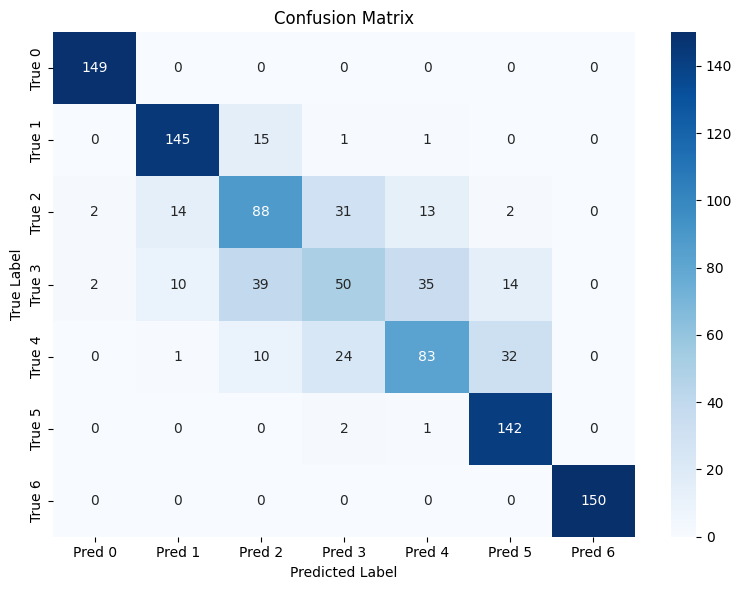

In [61]:
import seaborn as sns

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Pred {i}" for i in range(y_train.shape[1])],
            yticklabels=[f"True {i}" for i in range(y_train.shape[1])])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


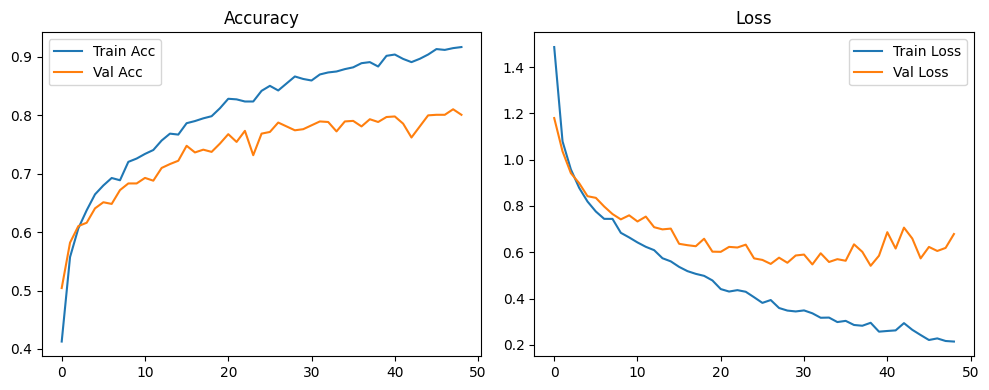

In [62]:

# === Plot training curves ===
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()
